# Demo: End-to-End Geospatial Classification

**This demo consists of:**
1. Load a YAML configuration file.
2. Use the package's data pipeline (`Dataset`, `DataLoader`, transforms).
3. Build and train the CNN and CNN-ViT hybrid models.
4. Evaluate using the package's metrics and plotting utilities.

In [1]:
import sys
from pathlib import Path

# Ensure the source package is on the path (if running outside of an installed env)
sys.path.insert(0, str(Path("..").resolve() / "src"))

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import DataLoader
from torchvision import datasets

from geospatial_classification.config import get_device, load_config
from geospatial_classification.data import ensure_extracted, load_or_create_splits
from geospatial_classification.data.transforms import get_inference_transform, get_train_transform, get_val_transform
from geospatial_classification.evaluation import plot_roc, print_metrics
from geospatial_classification.evaluation.plots import plot_training_curves
from geospatial_classification.models import ConvNet, CNN_ViT_Hybrid
from geospatial_classification.training import fit, load_checkpoint, set_seed, worker_init_fn
from geospatial_classification.utils import setup_logging

setup_logging(level=logging.INFO)

## Note on Reproducibility & Training Variability

This notebook uses fixed random seeds (`seed=42` for CNN, `seed=7331` for hybrid) to make data splits and weight initialization deterministic. However, you may still notice that training curves inside this notebook differ slightly between runs or when comparing with CLI/Docker outputs that will be created inside /plots once you did the training (e.g. after running PYTORCH_INDEX=https://download.pytorch.org/whl/nightly/cu128 USE_PRE=1 ./run-docker.sh)

This is normal in deep learning due to:

- **CUDA non-determinism:** GPU floating-point operations have inherent randomness that cannot be fully eliminated
- **PyTorch version differences:** Nightly vs. stable builds may use different CUDA kernels
- **Hardware/environment differences:** Notebook vs. Docker vs. different machines

**What matters:** The final evaluation metrics (Accuracy, ROC-AUC, F1) - not the exact curve shape. Both notebook and CLI pipelines should consistently achieve ~99%+ accuracy and ~0.999 ROC-AUC.

## 1. Configuration & Reproducibility

In [3]:
cfg = load_config("../configs/train_cnn.yaml")
print(cfg)

{'data': {'dataset_path': 'data/raw/images_dataSAT', 'img_size': 64, 'batch_size': 128, 'train_split': 0.8, 'num_workers': 4}, 'model': {'num_classes': 2, 'checkpoint_name': 'checkpoints/cnn_best.pth'}, 'training': {'epochs': 20, 'lr': 0.001, 'seed': 42, 'device': 'auto', 'early_stopping': {'patience': 3}}, 'logging': {'level': 'INFO', 'log_file': 'logs/train_cnn.log'}}


In [4]:
seed = cfg["training"]["seed"]
set_seed(seed)
device = get_device() if cfg["training"].get("device") == "auto" else cfg["training"]["device"]
print(f"Device: {device}")

2026-06-09 23:44:10,582 | INFO     | geospatial_classification.training.utils | Global seed set to 42
Device: cuda


## 2. Data Pipeline

In [5]:
ds_cfg = cfg["data"]
img_size = ds_cfg["img_size"]
batch_size = ds_cfg["batch_size"]
# Resolve path relative to the repo root (this notebook lives in notebooks/)
dataset_path = str(Path("..") / ds_cfg["dataset_path"])

# Auto-extract if necessary and load cached train/val splits
ensure_extracted(dataset_path=dataset_path)

train_transform = get_train_transform(img_size)
val_transform = get_val_transform(img_size)

full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
train_dataset, val_dataset = load_or_create_splits(
    full_dataset,
    train_split=ds_cfg["train_split"],
    seed=seed,
    processed_dir=str(Path("..") / "data" / "processed"),
)
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

2026-06-09 23:44:12,538 | INFO     | geospatial_classification.data.setup | Dataset already present at ../data/raw/images_dataSAT
2026-06-09 23:44:12,593 | INFO     | geospatial_classification.data.setup | Loading cached split indices from ../data/processed/split_indices_train0.8_seed42.json
Train samples: 4800 | Val samples: 1200


## 3. Train CNN Backbone

In [6]:
model = ConvNet(num_classes=cfg["model"]["num_classes"]).to(device)
print(model)

ConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): Conv2d(128, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (13): ReLU(inplace=

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg["training"]["lr"])

patience = cfg["training"].get("early_stopping", {}).get("patience")

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=cfg["training"]["epochs"],
    checkpoint_path=cfg["model"]["checkpoint_name"],
    patience=patience,
)

2026-06-09 23:44:17,250 | INFO     | geospatial_classification.training.loops | Epoch 1/20


2026-06-09 23:44:19,679 | INFO     | geospatial_classification.training.loops | Train loss: 0.2534 | accuracy: 0.9456


2026-06-09 23:44:20,121 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0368 | accuracy: 0.9892


2026-06-09 23:44:20,305 | INFO     | geospatial_classification.training.loops | Saved new best checkpoint to checkpoints/cnn_best.pth
2026-06-09 23:44:20,306 | INFO     | geospatial_classification.training.loops | Epoch 2/20


2026-06-09 23:44:21,701 | INFO     | geospatial_classification.training.loops | Train loss: 0.0260 | accuracy: 0.9927


...

2026-06-09 23:44:27,107 | INFO     | geospatial_classification.training.loops | Val   loss: 0.1528 | accuracy: 0.9458
2026-06-09 23:44:27,108 | INFO     | geospatial_classification.training.loops | Epoch 6/20


2026-06-09 23:44:28,447 | INFO     | geospatial_classification.training.loops | Train loss: 0.0246 | accuracy: 0.9919


2026-06-09 23:44:28,590 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0145 | accuracy: 0.9950
2026-06-09 23:44:28,591 | INFO     | geospatial_classification.training.loops | Epoch 7/20


2026-06-09 23:44:29,919 | INFO     | geospatial_classification.training.loops | Train loss: 0.0232 | accuracy: 0.9925


2026-06-09 23:44:30,162 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0470 | accuracy: 0.9842
2026-06-09 23:44:30,162 | INFO     | geospatial_classification.training.loops | Early stopping triggered after 7 epochs (no improvement for 3 epochs).


## 4. Visualise Training Curves

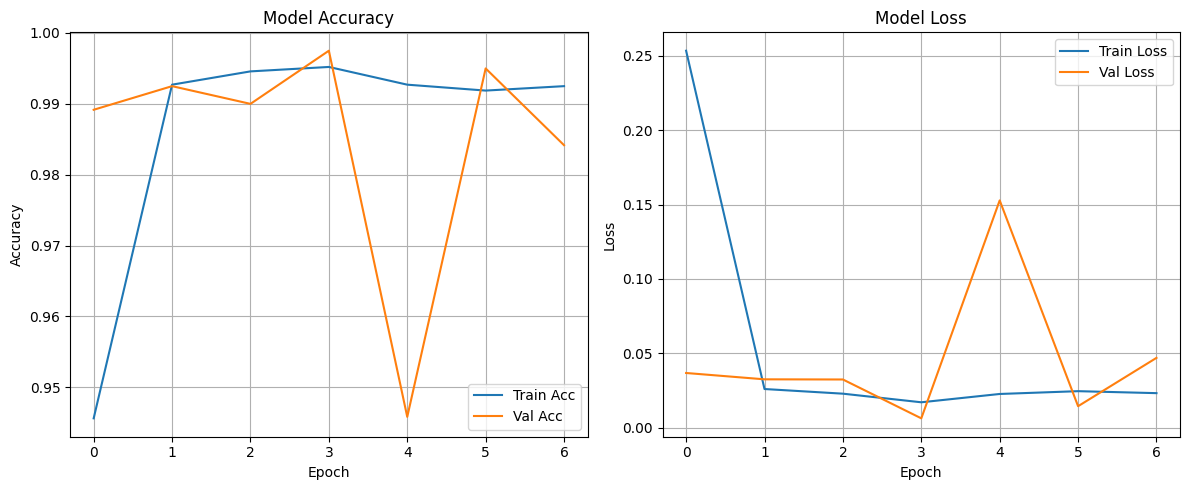

In [8]:
plot_training_curves(history)

## 5. Upgrade to CNN-ViT Hybrid (optional)

Load the saved CNN weights into the hybrid and continue training.

In [9]:
from geospatial_classification.training import load_checkpoint

hybrid_cfg = load_config("../configs/train_hybrid.yaml")

hybrid = CNN_ViT_Hybrid(
    num_classes=hybrid_cfg["model"]["num_classes"],
    embed_dim=hybrid_cfg["model"]["embed_dim"],
    depth=hybrid_cfg["model"]["depth"],
    heads=hybrid_cfg["model"]["heads"],
).to(device)

# Transfer learning from the CNN we just trained
cnn_path = hybrid_cfg["model"]["pretrained_cnn_path"]
if Path(cnn_path).exists():
    load_checkpoint(hybrid.cnn, cnn_path, device=device, strict=False)
    print(f"Loaded CNN backbone from {cnn_path}")
else:
    print(f"Warning: {cnn_path} not found. Training from scratch.")

2026-06-09 23:44:36,015 | INFO     | geospatial_classification.training.utils | Loaded state_dict from checkpoints/cnn_best.pth
Loaded CNN backbone from checkpoints/cnn_best.pth


In [10]:
# Rebuild loaders with hybrid config batch size
hybrid_ds_cfg = hybrid_cfg["data"]
hybrid_batch = hybrid_ds_cfg["batch_size"]
hybrid_train_loader = DataLoader(train_dataset, batch_size=hybrid_batch, shuffle=True, num_workers=2)
hybrid_val_loader = DataLoader(val_dataset, batch_size=hybrid_batch, shuffle=False, num_workers=2)

hybrid_optimizer = optim.Adam(hybrid.parameters(), lr=hybrid_cfg["training"]["lr"])

hybrid_patience = hybrid_cfg["training"].get("early_stopping", {}).get("patience")

hybrid_history = fit(
    model=hybrid,
    train_loader=hybrid_train_loader,
    val_loader=hybrid_val_loader,
    optimizer=hybrid_optimizer,
    criterion=criterion,
    device=device,
    epochs=hybrid_cfg["training"]["epochs"],
    checkpoint_path=hybrid_cfg["model"]["checkpoint_name"],
    patience=hybrid_patience,
)

2026-06-09 23:44:38,403 | INFO     | geospatial_classification.training.loops | Epoch 1/20


2026-06-09 23:44:43,188 | INFO     | geospatial_classification.training.loops | Train loss: 0.1964 | accuracy: 0.9546


2026-06-09 23:44:43,481 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0200 | accuracy: 0.9908


2026-06-09 23:44:43,729 | INFO     | geospatial_classification.training.loops | Saved new best checkpoint to checkpoints/hybrid_best.pth
2026-06-09 23:44:43,730 | INFO     | geospatial_classification.training.loops | Epoch 2/20


2026-06-09 23:44:48,463 | INFO     | geospatial_classification.training.loops | Train loss: 0.0680 | accuracy: 0.9815


2026-06-09 23:44:48,759 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0788 | accuracy: 0.9708
2026-06-09 23:44:48,759 | INFO     | geospatial_classification.training.loops | Epoch 3/20


2026-06-09 23:44:53,502 | INFO     | geospatial_classification.training.loops | Train loss: 0.0827 | accuracy: 0.9744


2026-06-09 23:44:53,776 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0782 | accuracy: 0.9825
2026-06-09 23:44:53,777 | INFO     | geospatial_classification.training.loops | Epoch 4/20


2026-06-09 23:44:58,465 | INFO     | geospatial_classification.training.loops | Train loss: 0.0661 | accuracy: 0.9783


2026-06-09 23:44:58,740 | INFO     | geospatial_classification.training.loops | Val   loss: 0.0740 | accuracy: 0.9825
2026-06-09 23:44:58,741 | INFO     | geospatial_classification.training.loops | Early stopping triggered after 4 epochs (no improvement for 3 epochs).


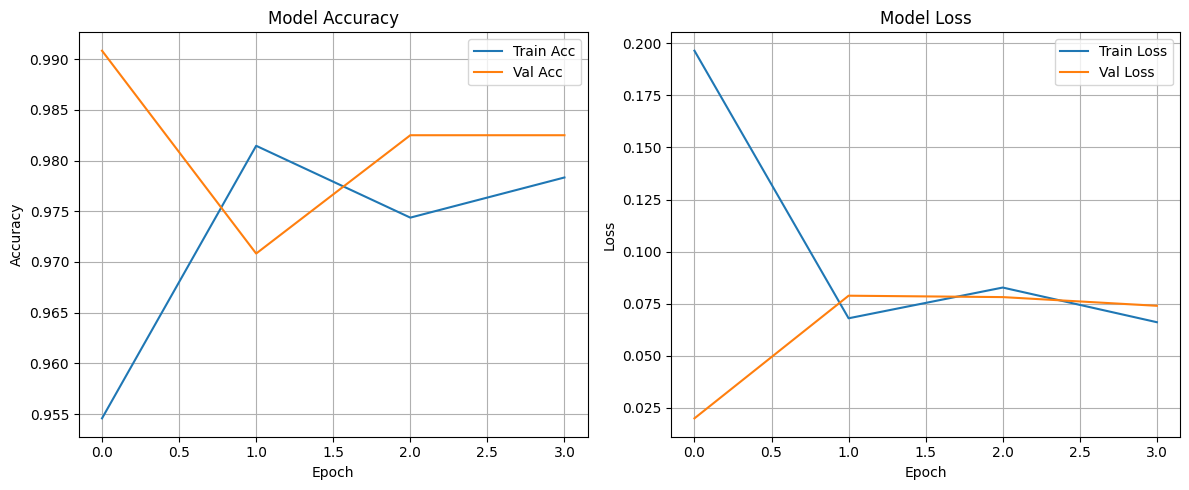

In [11]:
plot_training_curves(hybrid_history)

> **Reminder:** Notice the curve shape? Remember that CUDA non-determinism means training curves vary between runs, but the final evaluation metrics (Accuracy, ROC-AUC, F1) stay consistently high. The exact path to convergence matters less than where you end up.

## 6. Evaluate the Trained Hybrid

Load the best hybrid checkpoint and run rigorous evaluation on the full dataset.

In [12]:
# Rebuild evaluation dataset with inference transforms (no augmentation)
eval_transform = get_inference_transform((img_size, img_size))
eval_dataset = datasets.ImageFolder(dataset_path, transform=eval_transform)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

# Load the trained hybrid
eval_model = CNN_ViT_Hybrid(
    num_classes=hybrid_cfg["model"]["num_classes"],
    embed_dim=hybrid_cfg["model"]["embed_dim"],
    depth=hybrid_cfg["model"]["depth"],
    heads=hybrid_cfg["model"]["heads"],
).to(device)

# Load best checkpoint
hybrid_path = hybrid_cfg["model"]["checkpoint_name"]
if Path(hybrid_path).exists():
    state = torch.load(hybrid_path, map_location=torch.device(device))
    if "state_dict" in state:
        eval_model.load_state_dict(state["state_dict"], strict=False)
    else:
        eval_model.load_state_dict(state, strict=False)
    print(f"Loaded hybrid checkpoint from {hybrid_path}")
else:
    print(f"Warning: checkpoint not found at {hybrid_path}")

# Run inference
eval_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in eval_loader:
        images = images.to(device)
        outputs = eval_model(images)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)
print(f"Evaluated on {len(y_true)} samples")

Loaded hybrid checkpoint from checkpoints/hybrid_best.pth
Evaluated on 6000 samples


In [13]:
class_labels = ["non-agri", "agri"]
print_metrics(y_true, y_pred, y_prob, class_labels, "PyTorch CNN-ViT Hybrid")

2026-06-09 23:45:09,467 | INFO     | geospatial_classification.evaluation.metrics | ============================================================
2026-06-09 23:45:09,467 | INFO     | geospatial_classification.evaluation.metrics | Evaluation Report — PyTorch CNN-ViT Hybrid
2026-06-09 23:45:09,468 | INFO     | geospatial_classification.evaluation.metrics | ============================================================
2026-06-09 23:45:09,468 | INFO     | geospatial_classification.evaluation.metrics | Accuracy: 0.9945
2026-06-09 23:45:09,468 | INFO     | geospatial_classification.evaluation.metrics | Precision: 0.9945
2026-06-09 23:45:09,469 | INFO     | geospatial_classification.evaluation.metrics | Recall: 0.9945
2026-06-09 23:45:09,469 | INFO     | geospatial_classification.evaluation.metrics | F1 Score: 0.9945


2026-06-09 23:45:09,469 | INFO     | geospatial_classification.evaluation.metrics | ROC-AUC: 0.9999
2026-06-09 23:45:09,470 | INFO     | geospatial_classification.evaluation.metrics | Log Loss: 0.0144
2026-06-09 23:45:09,470 | INFO     | geospatial_classification.evaluation.metrics | Confusion Matrix:
[[2970   30]
 [   3 2997]]
2026-06-09 23:45:09,471 | INFO     | geospatial_classification.evaluation.metrics | Classification Report:
              precision    recall  f1-score   support

    non-agri       1.00      0.99      0.99      3000
        agri       0.99      1.00      0.99      3000

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



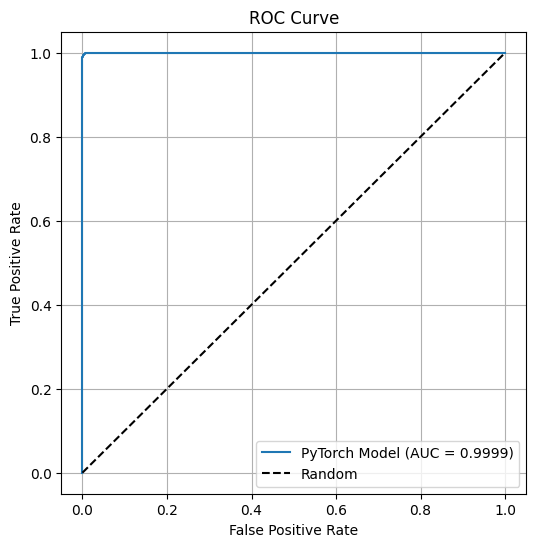

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_roc(y_true, y_prob, "PyTorch Model", ax=ax)
plt.show()

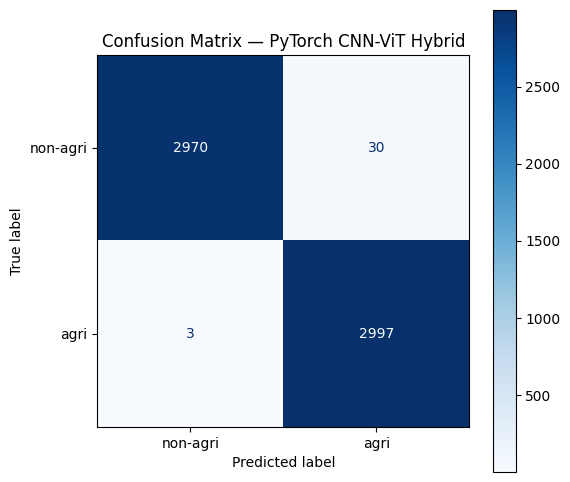

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=class_labels, ax=ax, cmap="Blues"
)
ax.set_title("Confusion Matrix — PyTorch CNN-ViT Hybrid")
plt.show()